# Assignment 3 – Q1
## Tackling Mode Collapse in GANs: DCGAN vs WGAN-GP
### Mehar Akbar 22f8796     Javeria Rehman 22f3352
**Datasets:**
- [Pokemon Sprites](https://www.kaggle.com/datasets/jackemartin/pokemon-sprites)
- [Anime Faces 64×64](https://www.kaggle.com/datasets/soumikrakshit/anime-faces)

## 1. Environment Setup & Imports

In [18]:
# ── Install optional dependencies ────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'gradio', 'scikit-image', '-q'], capture_output=True)

# ── Standard imports ─────────────────────────────────────────────────────────
import os, sys, random, time, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torchvision.utils as vutils
from torch.cuda.amp import GradScaler, autocast

from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.device_count() >= 2:
    print(f'✅ Using {torch.cuda.device_count()} GPUs')
elif torch.cuda.is_available():
    print('✅ Using single GPU')
else:
    print('⚠️  Using CPU — training will be slow')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'   GPU {i}: {torch.cuda.get_device_name(i)}')

# ── Shared helper ─────────────────────────────────────────────────────────────
def denorm(t):
    """Denormalize tensor from [-1,1] to [0,1]."""
    return (t * 0.5 + 0.5).clamp(0, 1)

def to_numpy_img(t):
    return np.transpose(denorm(t.cpu()).numpy(), (1, 2, 0))

def weights_init(m):
    """DCGAN-style weight initialisation."""
    cls = m.__class__.__name__
    if 'Conv' in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

print('\n✅ Global setup complete.')

✅ Using 2 GPUs
   GPU 0: Tesla T4
   GPU 1: Tesla T4

✅ Global setup complete.


## 2. Hyperparameters & Configuration

In [19]:
# ── Q1 Config ─────────────────────────────────────────────────────────────────
Q1_IMG_SIZE   = 64
Q1_NC         = 3
Q1_NZ         = 100
Q1_NGF        = 64
Q1_NDF        = 64
Q1_BATCH      = 64
Q1_LR         = 0.0002
Q1_BETAS      = (0.5, 0.999)
Q1_EPOCHS_DC  = 50
Q1_EPOCHS_WG  = 60
Q1_N_CRITIC   = 5
Q1_LAMBDA_GP  = 10
Q1_SUBSET     = 5000
Q1_SAVE_EVERY = 10

Q1_ANIME_PATH   = '/kaggle/input/datasets/soumikrakshit/anime-faces'
Q1_POKEMON_PATH = '/kaggle/input/datasets/jackemartin/pokemon-sprites'
Q1_CKPT_DIR     = '/kaggle/working/q1_checkpoints'
os.makedirs(Q1_CKPT_DIR, exist_ok=True)

Q1_FIXED_NOISE = torch.randn(64, Q1_NZ, 1, 1, device=DEVICE)
print('Q1 config ready.')

Q1 config ready.


## 3. Data Preparation

  Found 43102 images in /kaggle/input/datasets/soumikrakshit/anime-faces
Subset: 5000 images | 78 batches/epoch


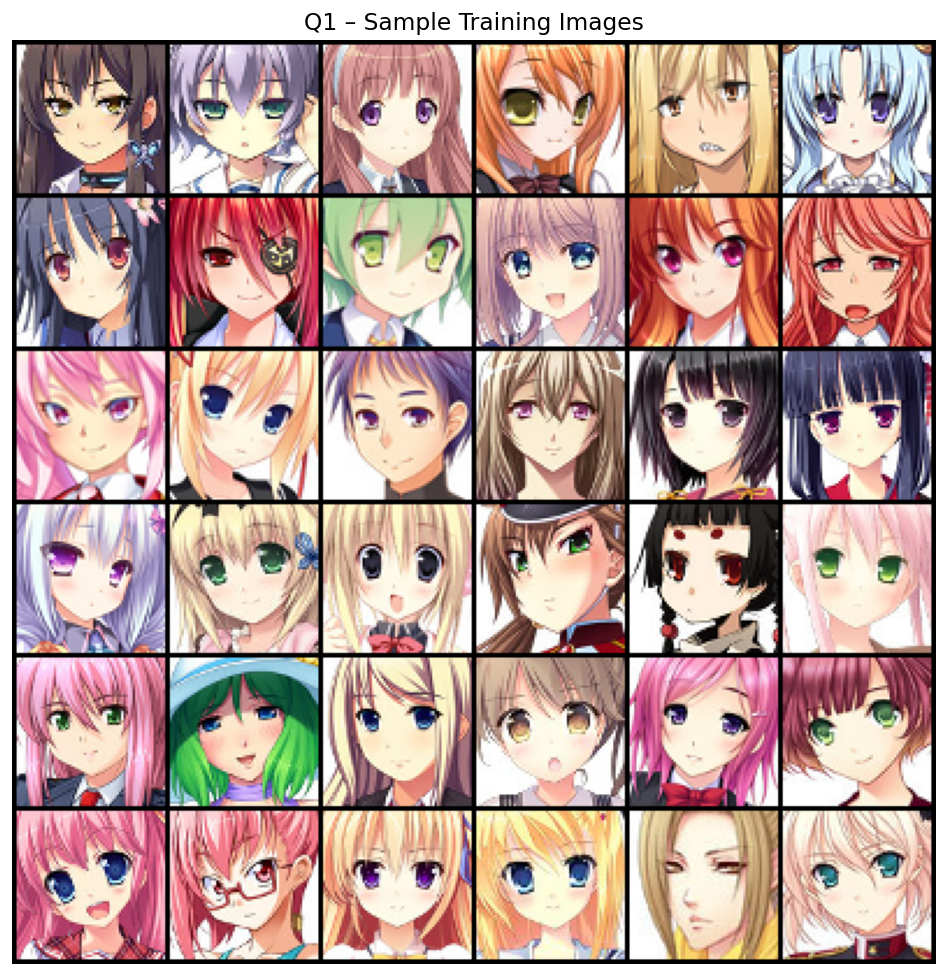

In [20]:
class Q1_ImageDataset(Dataset):
    EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

    def __init__(self, root, transform=None):
        self.paths = [p for p in Path(root).rglob('*') if p.suffix.lower() in self.EXTS]
        self.transform = transform
        print(f'  Found {len(self.paths)} images in {root}')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return (self.transform(img) if self.transform else img), 0


q1_transform = transforms.Compose([
    transforms.Resize(Q1_IMG_SIZE),
    transforms.CenterCrop(Q1_IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# Load whichever dataset exists
q1_ds = None
for path in [Q1_ANIME_PATH, Q1_POKEMON_PATH]:
    if os.path.exists(path):
        try:
            q1_ds = Q1_ImageDataset(path, q1_transform)
            if len(q1_ds) > 0: break
        except: pass

if q1_ds is None:
    raise RuntimeError('Q1: No dataset found. Add anime-faces or pokemon-sprites to Kaggle.')

idx = random.sample(range(len(q1_ds)), min(Q1_SUBSET, len(q1_ds)))
q1_subset    = Subset(q1_ds, idx)
q1_loader    = DataLoader(q1_subset, Q1_BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)

print(f'Subset: {len(q1_subset)} images | {len(q1_loader)} batches/epoch')

# Sample grid
real_batch, _ = next(iter(q1_loader))
plt.figure(figsize=(10,10))
plt.axis('off'); plt.title('Q1 – Sample Training Images', fontsize=14)
plt.imshow(np.transpose(vutils.make_grid(real_batch[:36], nrow=6, normalize=True).cpu(),(1,2,0)))
plt.savefig('/kaggle/working/q1_training_samples.png', bbox_inches='tight')
plt.show()

## 4. Baseline Model: DCGAN

In [21]:
class DCGAN_Generator(nn.Module):
    """DCGAN Generator: z(100) → 64×64 RGB via Transposed Convolutions."""
    def __init__(self, nz=Q1_NZ, ngf=Q1_NGF, nc=Q1_NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz,    ngf*8, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1, bias=False), nn.BatchNorm2d(ngf),   nn.ReLU(True),
            nn.ConvTranspose2d(ngf,   nc,    4, 2, 1, bias=False), nn.Tanh()
        )
    def forward(self, z): return self.main(z)


class DCGAN_Discriminator(nn.Module):
    """DCGAN Discriminator: 64×64 RGB → scalar via Strided Convolutions + Sigmoid."""
    def __init__(self, ndf=Q1_NDF, nc=Q1_NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc,    ndf,   4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf,   ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*8, 1,     4, 1, 0, bias=False)  # Sigmoid removed — BCEWithLogitsLoss handles it
        )
    def forward(self, x): return self.main(x).view(-1)


# ── Instantiate DCGAN ─────────────────────────────────────────────────────────
netG_dc = DCGAN_Generator().to(DEVICE)
netD_dc = DCGAN_Discriminator().to(DEVICE)
if torch.cuda.device_count() > 1:
    netG_dc = nn.DataParallel(netG_dc)
    netD_dc = nn.DataParallel(netD_dc)
netG_dc.apply(weights_init); netD_dc.apply(weights_init)

print('DCGAN Generator:');     print(netG_dc)
print('\nDCGAN Discriminator:'); print(netD_dc)

DCGAN Generator:
DataParallel(
  (module): DCGAN_Generator(
    (main): Sequential(
      (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU(inplace=True)
      (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU(inplace=True)
      (12): ConvTranspose2d(64, 3, kernel_si

## 5. DCGAN Training

In [22]:
criterion_bce = nn.BCEWithLogitsLoss()
optimD_dc = optim.Adam(netD_dc.parameters(), lr=Q1_LR, betas=Q1_BETAS)
optimG_dc = optim.Adam(netG_dc.parameters(), lr=Q1_LR, betas=Q1_BETAS)
scaler_dc  = GradScaler()

dc_G_losses, dc_D_losses = [], []
dc_img_list = []

print('Starting DCGAN training...')
print('='*65)
t0 = time.time()

for epoch in range(Q1_EPOCHS_DC):
    netG_dc.train(); netD_dc.train()
    ep_G = ep_D = 0.0

    for real_imgs, _ in q1_loader:
        real_imgs = real_imgs.to(DEVICE)
        b = real_imgs.size(0)
        lbl_r = torch.full((b,), 1.0, device=DEVICE)
        lbl_f = torch.full((b,), 0.0, device=DEVICE)

        # Discriminator
        netD_dc.zero_grad()
        with autocast():
            noise     = torch.randn(b, Q1_NZ, 1, 1, device=DEVICE)
            fake_imgs = netG_dc(noise)
            lossD     = (criterion_bce(netD_dc(real_imgs), lbl_r) +
                         criterion_bce(netD_dc(fake_imgs.detach()), lbl_f))
        scaler_dc.scale(lossD).backward()
        scaler_dc.step(optimD_dc); scaler_dc.update()

        # Generator
        netG_dc.zero_grad()
        with autocast():
            lossG = criterion_bce(netD_dc(fake_imgs), lbl_r)
        scaler_dc.scale(lossG).backward()
        scaler_dc.step(optimG_dc); scaler_dc.update()

        ep_G += lossG.item(); ep_D += lossD.item()

    avg_G = ep_G / len(q1_loader)
    avg_D = ep_D / len(q1_loader)
    dc_G_losses.append(avg_G); dc_D_losses.append(avg_D)

    print(f'[DCGAN] Epoch {epoch+1:3d}/{Q1_EPOCHS_DC}  '
          f'Loss_D: {avg_D:.4f}  Loss_G: {avg_G:.4f}  '
          f'({(time.time()-t0)/60:.1f} min)')

    if (epoch+1) % 10 == 0 or epoch == 0:
        with torch.no_grad(): dc_img_list.append(netG_dc(Q1_FIXED_NOISE).detach().cpu())

    if (epoch+1) % Q1_SAVE_EVERY == 0:
        torch.save(netG_dc.state_dict(), f'{Q1_CKPT_DIR}/dcgan_G_ep{epoch+1}.pth')
        torch.save(netD_dc.state_dict(), f'{Q1_CKPT_DIR}/dcgan_D_ep{epoch+1}.pth')

print(f'✅ DCGAN done in {(time.time()-t0)/60:.1f} min')

Starting DCGAN training...
[DCGAN] Epoch   1/50  Loss_D: 0.9131  Loss_G: 11.1767  (0.3 min)
[DCGAN] Epoch   2/50  Loss_D: 0.8307  Loss_G: 9.2665  (0.6 min)
[DCGAN] Epoch   3/50  Loss_D: 0.7535  Loss_G: 7.3554  (0.9 min)
[DCGAN] Epoch   4/50  Loss_D: 0.7332  Loss_G: 6.9015  (1.1 min)
[DCGAN] Epoch   5/50  Loss_D: 0.5856  Loss_G: 6.3318  (1.4 min)
[DCGAN] Epoch   6/50  Loss_D: 0.7060  Loss_G: 6.7109  (1.7 min)
[DCGAN] Epoch   7/50  Loss_D: 0.5821  Loss_G: 6.2406  (2.0 min)
[DCGAN] Epoch   8/50  Loss_D: 0.6228  Loss_G: 6.3401  (2.2 min)
[DCGAN] Epoch   9/50  Loss_D: 0.5998  Loss_G: 5.8944  (2.5 min)
[DCGAN] Epoch  10/50  Loss_D: 0.7464  Loss_G: 6.4066  (2.8 min)
[DCGAN] Epoch  11/50  Loss_D: 0.6418  Loss_G: 5.9677  (3.1 min)
[DCGAN] Epoch  12/50  Loss_D: 0.5601  Loss_G: 5.8990  (3.4 min)
[DCGAN] Epoch  13/50  Loss_D: 0.4923  Loss_G: 6.0898  (3.6 min)
[DCGAN] Epoch  14/50  Loss_D: 0.4801  Loss_G: 6.2930  (3.9 min)
[DCGAN] Epoch  15/50  Loss_D: 0.5358  Loss_G: 6.0064  (4.2 min)
[DCGAN] Epoc

## 6. Advanced Model: WGAN-GP Architecture and Training

In [23]:
class WGAN_Generator(nn.Module):
    """WGAN-GP Generator — same as DCGAN Generator."""
    def __init__(self, nz=Q1_NZ, ngf=Q1_NGF, nc=Q1_NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz,    ngf*8, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1, bias=False), nn.BatchNorm2d(ngf),   nn.ReLU(True),
            nn.ConvTranspose2d(ngf,   nc,    4, 2, 1, bias=False), nn.Tanh()
        )
    def forward(self, z): 
        return self.main(z)


class WGAN_Critic(nn.Module):
    """WGAN-GP Critic — NO Sigmoid, InstanceNorm instead of BatchNorm."""
    def __init__(self, ndf=Q1_NDF, nc=Q1_NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc,    ndf,   4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf,   ndf*2, 4, 2, 1, bias=False), nn.InstanceNorm2d(ndf*2, affine=True), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.InstanceNorm2d(ndf*4, affine=True), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False), nn.InstanceNorm2d(ndf*8, affine=True), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*8, 1,     4, 1, 0, bias=False)   # No Sigmoid!
        )
    
    def forward(self, x): 
        return self.main(x).view(-1)


def compute_gradient_penalty(critic, real, fake, device):
    """WGAN-GP gradient penalty — FIXED: Convert interp to float32 BEFORE requires_grad."""
    b     = real.size(0)
    alpha = torch.rand(b, 1, 1, 1, device=device, dtype=torch.float32)
    
    # Ensure everything is float32 for gradient computation
    real_f = real.float().detach()
    fake_f = fake.float().detach()
    interp = (alpha * real_f + (1 - alpha) * fake_f).requires_grad_(True)
    
    # Run critic with gradient tracking (no autocast here!)
    score = critic(interp)
    
    # Compute gradients
    grad = torch.autograd.grad(
        outputs=score, inputs=interp,
        grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True, only_inputs=True,
        allow_unused=False
    )[0].view(b, -1)
    
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()


# Initialize networks
netG_wgan = WGAN_Generator().to(DEVICE)
netC_wgan = WGAN_Critic().to(DEVICE)
if torch.cuda.device_count() > 1:
    netG_wgan = nn.DataParallel(netG_wgan)
    netC_wgan = nn.DataParallel(netC_wgan)
netG_wgan.apply(weights_init)
netC_wgan.apply(weights_init)

optimG_wgan = optim.Adam(netG_wgan.parameters(), lr=Q1_LR, betas=Q1_BETAS)
optimC_wgan = optim.Adam(netC_wgan.parameters(), lr=Q1_LR, betas=Q1_BETAS)
scaler_wg   = GradScaler()

wgan_G, wgan_C, wgan_GP = [], [], []
wgan_img_list = []

print('Starting WGAN-GP training...')
print('='*65)
t0 = time.time()

for epoch in range(Q1_EPOCHS_WG):
    netG_wgan.train()
    netC_wgan.train()
    ep_G = ep_C = ep_gp = 0.0
    data_iter   = iter(q1_loader)
    batch_count = 0

    while True:
        # Train Critic N times
        c_iters = 0
        while c_iters < Q1_N_CRITIC:
            try: 
                real_imgs, _ = next(data_iter)
            except StopIteration: 
                data_iter = None
                break
            
            real_imgs = real_imgs.to(DEVICE)
            b = real_imgs.size(0)

            netC_wgan.zero_grad()
            
            # Generate fake images with autocast
            with autocast():
                noise     = torch.randn(b, Q1_NZ, 1, 1, device=DEVICE)
                fake_imgs = netG_wgan(noise)
                w_loss    = netC_wgan(fake_imgs.detach()).mean() - netC_wgan(real_imgs).mean()
            
            # GP computed OUTSIDE autocast in full float32
            gp = compute_gradient_penalty(netC_wgan, real_imgs, fake_imgs, DEVICE)
            loss_C = w_loss.float() + Q1_LAMBDA_GP * gp
            
            # Backward pass
            loss_C.backward()
            optimC_wgan.step()

            ep_C += w_loss.item()
            ep_gp += gp.item()
            c_iters += 1
            batch_count += 1

        if data_iter is None: 
            break

        # Train Generator
        netG_wgan.zero_grad()
        noise = torch.randn(b, Q1_NZ, 1, 1, device=DEVICE)
        with autocast():
            lossG = -netC_wgan(netG_wgan(noise)).mean()
        scaler_wg.scale(lossG).backward()
        scaler_wg.step(optimG_wgan)
        scaler_wg.update()
        ep_G += lossG.item()

    n = max(batch_count, 1)
    wgan_G.append(ep_G / (n / Q1_N_CRITIC))
    wgan_C.append(ep_C / n)
    wgan_GP.append(ep_gp / n)

    print(f'[WGAN-GP] Epoch {epoch+1:3d}/{Q1_EPOCHS_WG}  '
          f'Loss_C: {wgan_C[-1]:.4f}  Loss_G: {wgan_G[-1]:.4f}  '
          f'GP: {wgan_GP[-1]:.4f}  ({(time.time()-t0)/60:.1f} min)')

    if (epoch+1) % 10 == 0 or epoch == 0:
        with torch.no_grad(): 
            wgan_img_list.append(netG_wgan(Q1_FIXED_NOISE).detach().cpu())

    if (epoch+1) % Q1_SAVE_EVERY == 0:
        torch.save(netG_wgan.state_dict(), f'{Q1_CKPT_DIR}/wgan_G_ep{epoch+1}.pth')
        torch.save(netC_wgan.state_dict(), f'{Q1_CKPT_DIR}/wgan_C_ep{epoch+1}.pth')

print(f'✅ WGAN-GP done in {(time.time()-t0)/60:.1f} min')

Starting WGAN-GP training...
[WGAN-GP] Epoch   1/60  Loss_C: -6.8457  Loss_G: 3.8924  GP: 2.9656  (0.4 min)
[WGAN-GP] Epoch   2/60  Loss_C: -8.1530  Loss_G: 2.3415  GP: 0.2638  (0.8 min)
[WGAN-GP] Epoch   3/60  Loss_C: -11.9197  Loss_G: 3.9601  GP: 0.2376  (1.2 min)
[WGAN-GP] Epoch   4/60  Loss_C: -15.2015  Loss_G: 5.5586  GP: 0.2897  (1.5 min)
[WGAN-GP] Epoch   5/60  Loss_C: -19.3802  Loss_G: 6.5370  GP: 0.3671  (1.9 min)
[WGAN-GP] Epoch   6/60  Loss_C: -20.3670  Loss_G: 8.1601  GP: 0.4170  (2.3 min)
[WGAN-GP] Epoch   7/60  Loss_C: -25.2817  Loss_G: 13.9278  GP: 0.5549  (2.7 min)
[WGAN-GP] Epoch   8/60  Loss_C: -29.7071  Loss_G: 17.6382  GP: 0.7034  (3.1 min)
[WGAN-GP] Epoch   9/60  Loss_C: -31.5659  Loss_G: 20.6060  GP: 0.7291  (3.5 min)
[WGAN-GP] Epoch  10/60  Loss_C: -32.2678  Loss_G: 22.4569  GP: 0.7789  (3.8 min)
[WGAN-GP] Epoch  11/60  Loss_C: -30.4247  Loss_G: 22.4539  GP: 0.7420  (4.2 min)
[WGAN-GP] Epoch  12/60  Loss_C: -27.4431  Loss_G: 23.2171  GP: 0.6323  (4.6 min)
[WGAN-G

## 7. WGAN-GP Training Log and Visualization

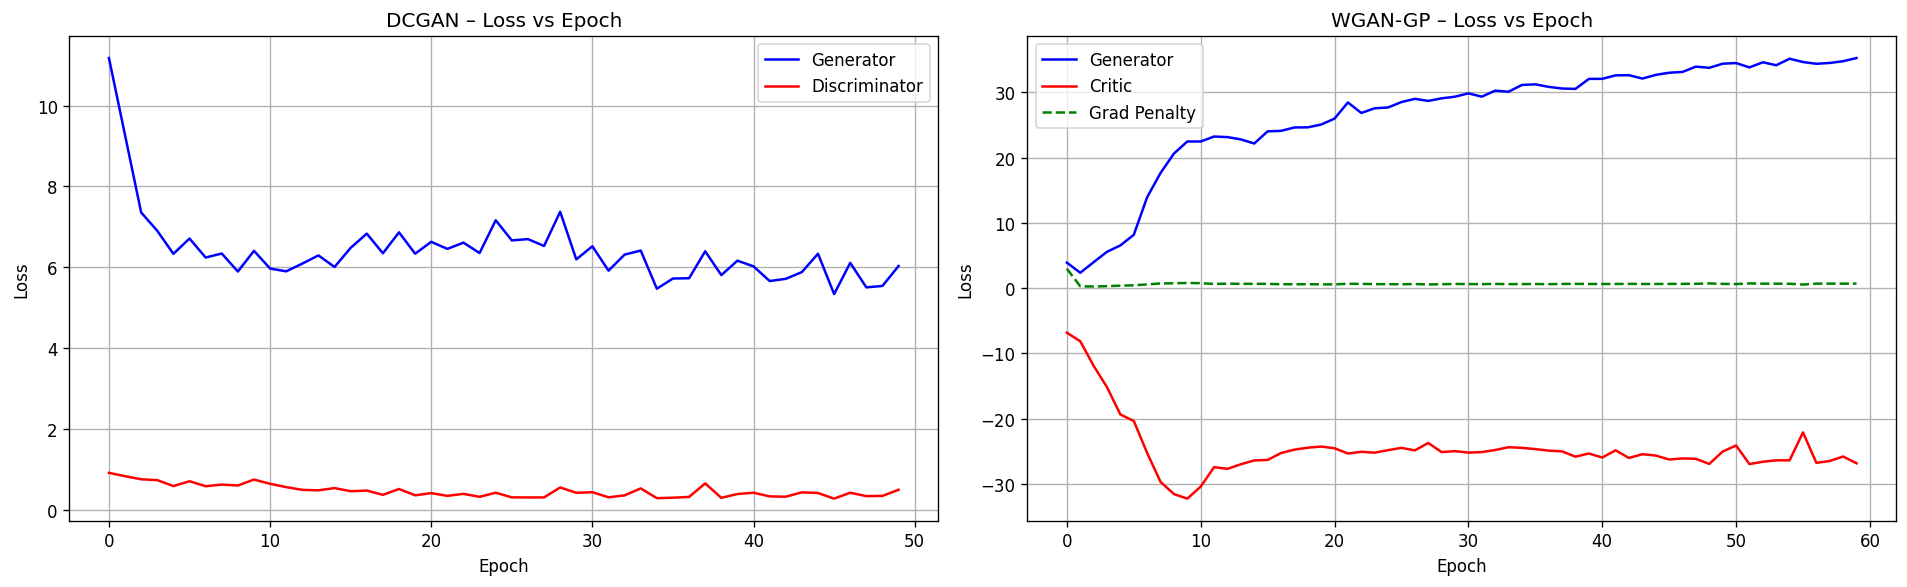

In [24]:
# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(dc_G_losses, label='Generator',     color='blue')
axes[0].plot(dc_D_losses, label='Discriminator', color='red')
axes[0].set_title('DCGAN – Loss vs Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(wgan_G,  label='Generator', color='blue')
axes[1].plot(wgan_C,  label='Critic',    color='red')
axes[1].plot(wgan_GP, label='Grad Penalty', color='green', linestyle='--')
axes[1].set_title('WGAN-GP – Loss vs Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/q1_losses.png', bbox_inches='tight')
plt.show()

## 8. Visualization & Comparison

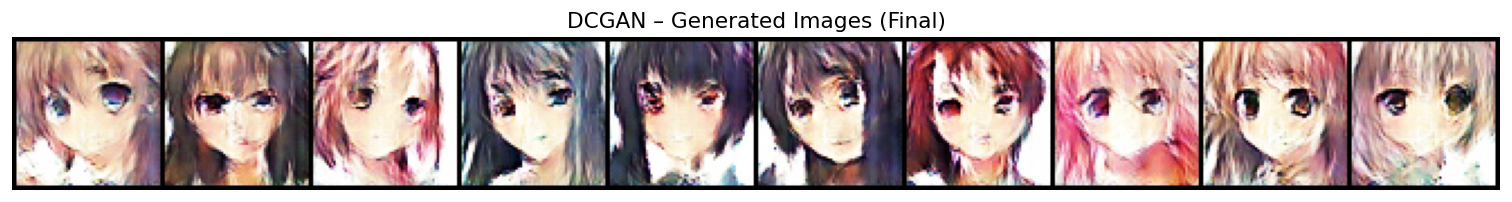

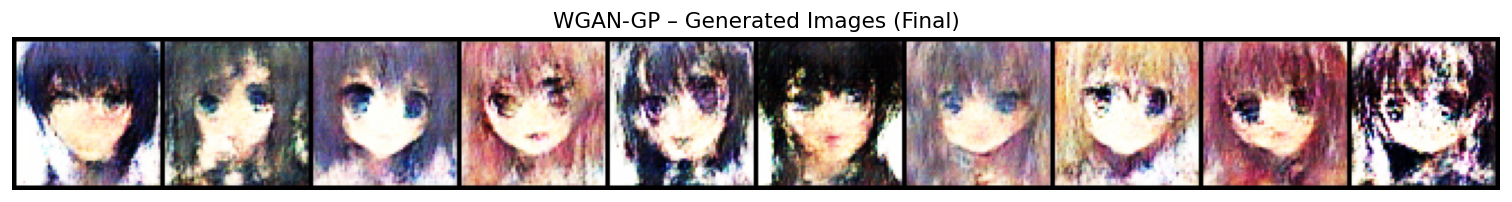

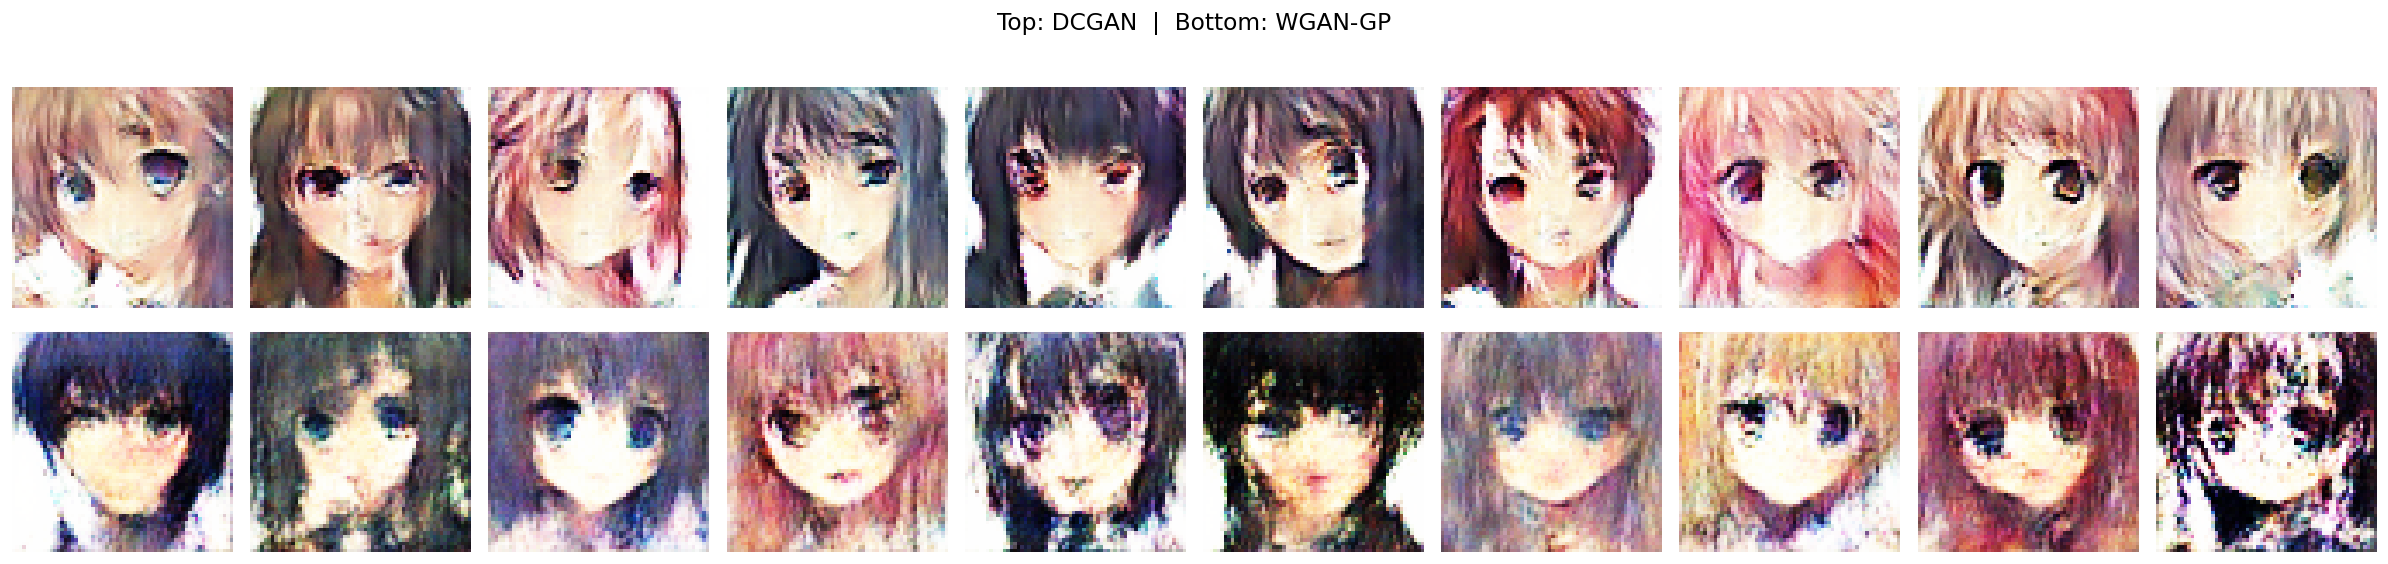

In [25]:
# Generated images — final epoch
netG_dc.eval(); netG_wgan.eval()
with torch.no_grad():
    final_dc   = netG_dc(Q1_FIXED_NOISE).detach().cpu()
    final_wgan = netG_wgan(Q1_FIXED_NOISE).detach().cpu()

def show_grid(imgs, title, n=10, save=None):
    grid = vutils.make_grid(imgs[:n], nrow=n, padding=2, normalize=True)
    plt.figure(figsize=(n*1.6, 2.5))
    plt.axis('off'); plt.title(title, fontsize=13)
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    if save: plt.savefig(save, bbox_inches='tight')
    plt.show()

show_grid(final_dc,   'DCGAN – Generated Images (Final)',   save='/kaggle/working/q1_dcgan_final.png')
show_grid(final_wgan, 'WGAN-GP – Generated Images (Final)', save='/kaggle/working/q1_wgangp_final.png')

# Side-by-side comparison
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Top: DCGAN  |  Bottom: WGAN-GP', fontsize=14)
for j in range(10):
    axes[0, j].imshow(to_numpy_img(final_dc[j]));   axes[0, j].axis('off')
    axes[1, j].imshow(to_numpy_img(final_wgan[j])); axes[1, j].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/q1_comparison.png', bbox_inches='tight')
plt.show()

## 9. Quantitative Evaluation (SSIM-based Diversity)

Diversity (Mean Pairwise L2 Distance — higher = less mode collapse)
  DCGAN   : 75.1996 ± 13.3391
  WGAN-GP : 77.1487 ± 15.2652


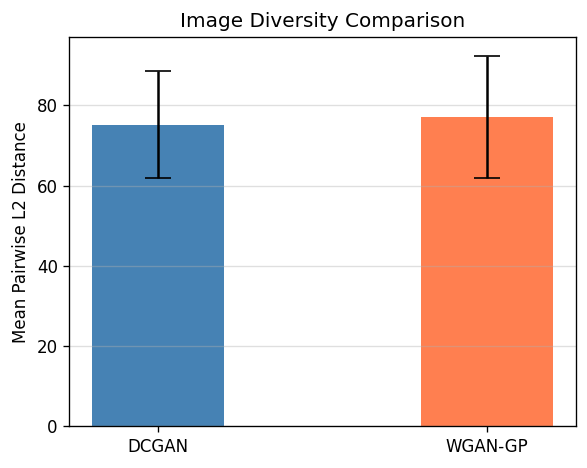

In [26]:
from itertools import combinations

def pairwise_diversity(imgs, k=10):
    flat  = imgs[:k].view(k, -1).float()
    pairs = list(combinations(range(k), 2))
    dists = [torch.dist(flat[i], flat[j]).item() for i, j in pairs]
    return np.mean(dists), np.std(dists)

dc_m, dc_s   = pairwise_diversity(final_dc)
wg_m, wg_s   = pairwise_diversity(final_wgan)

print('='*50)
print('Diversity (Mean Pairwise L2 Distance — higher = less mode collapse)')
print(f'  DCGAN   : {dc_m:.4f} ± {dc_s:.4f}')
print(f'  WGAN-GP : {wg_m:.4f} ± {wg_s:.4f}')
print('='*50)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['DCGAN', 'WGAN-GP'], [dc_m, wg_m], yerr=[dc_s, wg_s],
       color=['steelblue', 'coral'], capsize=8, width=0.4)
ax.set_title('Image Diversity Comparison'); ax.set_ylabel('Mean Pairwise L2 Distance')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/q1_diversity.png', bbox_inches='tight')
plt.show()

## 10. Gradio App Deployment

In [27]:
!pip install gradio -q

In [1]:
import gradio as gr

def q1_generate(model_name, num_images, seed):
    torch.manual_seed(int(seed))
    noise = torch.randn(int(num_images), Q1_NZ, 1, 1, device=DEVICE)
    net   = netG_dc if model_name == 'DCGAN' else netG_wgan
    net.eval()
    with torch.no_grad():
        imgs = net(noise).cpu()
    grid = vutils.make_grid(imgs, nrow=min(int(num_images), 5), normalize=True, padding=2)
    arr  = (np.transpose(grid.numpy(), (1,2,0)) * 255).clip(0,255).astype(np.uint8)
    return Image.fromarray(arr)

with gr.Blocks(title='Q1 – GAN Generator') as q1_app:
    gr.Markdown('## 🎨 Q1: DCGAN vs WGAN-GP Image Generator')
    with gr.Row():
        model_dd  = gr.Dropdown(['DCGAN', 'WGAN-GP'], value='DCGAN', label='Model')
        n_slider  = gr.Slider(1, 10, value=5, step=1, label='Number of Images')
        seed_sl   = gr.Slider(0, 9999, value=42, step=1, label='Seed')
    btn = gr.Button('Generate', variant='primary')
    out = gr.Image(label='Generated Images')
    btn.click(fn=q1_generate, inputs=[model_dd, n_slider, seed_sl], outputs=out)
    gr.Markdown('**DCGAN** uses BCE loss | **WGAN-GP** uses Wasserstein loss + Gradient Penalty (λ=10)')

q1_app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cd9e05bb62d4d01de5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^